
# mBART-50 (zh→en) — Baseline TF Training (Wuxia Domain)

**TFG – Baseline NMT (MarianMT)**  
Este cuaderno entrena y evalúa un modelo **MarianMT** (`Helsinki-NLP/opus-mt-zh-en`) con **TensorFlow** y **Hugging Face** usando un dataset paralelo **wuxia** (chino→inglés) ya preparado en formato `datasets` (HF).



> **Requisitos del dataset**: directorio HF Datasets con *splits* `train`, `validation`, `test` y columnas `zh` (chino) y `en` (inglés):  
> `processed_data/wuxia_zh_en_clean/`


## 1) Entorno de ejecución e instalación de dependencias

In [1]:


import os, random, math
import numpy as np

import torch
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Nombre de la GPU:", torch.cuda.get_device_name(0))



CUDA disponible: True
Número de GPUs: 1
Nombre de la GPU: NVIDIA GeForce RTX 3060


In [2]:
# Configuración de carpetas para entorno LOCAL
from pathlib import Path
BASE_DIR = Path.cwd().parent.parent
BASE_DIR.mkdir(exist_ok=True)

# Estructura repositorio
for sub in ["evaluation", "models", "processed_data"]:
    (BASE_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Base:", BASE_DIR.resolve())
print("Estructura creada (si no existía):")
for p in ["evaluation", "models", "proccesed data"]:
    print(" -", (BASE_DIR / p).resolve())

# Nota: el dataset debe existir en: CORPUS/proccesed data/wuxia_zh_en_clean


Base: C:\Users\Usuario\Desktop\TFG\CORPUS
Estructura creada (si no existía):
 - C:\Users\Usuario\Desktop\TFG\CORPUS\evaluation
 - C:\Users\Usuario\Desktop\TFG\CORPUS\models
 - C:\Users\Usuario\Desktop\TFG\CORPUS\proccesed data


## 2) Configuración

In [3]:
from dataclasses import dataclass

@dataclass
class Config:
    # Rutas (local)
    dataset_dir: Path  = BASE_DIR / "processed_data" / "wuxia_zh_en_clean"   # <- carpeta con dataset HuggingFace guardado con load_from_disk
    output_dir: Path   = BASE_DIR / "models" / "mbart50_wuxia_10" 
    # <- aquí se guardarán los runs/modelos
    ckpt_path: Path   =  BASE_DIR / "models" / "mbart50_wuxia_10" #/ "checkpoint-104304"                      
    training_dir: Path = BASE_DIR / "training"    
         
    evaluation_dir: Path = BASE_DIR / "evaluation"
    translate_dir: Path = BASE_DIR / "evaluation" / "translate"
    
    translate_file: Path =  "mbart_10.txt"
    results_file: Path = "results.txt"

    # Columnas del dataset
    src_col: str = "zh"
    tgt_col: str = "en"

    # Códigos de idioma mBART-50
    src_lang: str = "zh_CN"
    tgt_lang: str = "en_XX"

    # Modelo
    model_ckpt: str = "facebook/mbart-large-50-many-to-many-mmt"

    # Entrenamiento
    seed: int = 42
    max_source_length: int = 128
    max_target_length: int = 128
    batch_size: int = 16
    epochs: int = 5 # 600 MILLONES d parametros + una ejecucion de 10 epochs fallida por corte de luz llevan a esta cpnclusion
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    early_stopping_patience: int = 2
    # Usa todo el dataset en la ejecución final (ajusta si quieres depurar más rápido)
    fraction: float = 1

cfg = Config()
print(cfg)


Config(dataset_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/processed_data/wuxia_zh_en_clean'), output_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/models/mbart50_wuxia_10'), ckpt_path=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/models/mbart50_wuxia_10'), training_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/training'), evaluation_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation'), translate_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation/translate'), translate_file='mbart_10.txt', results_file='results.txt', src_col='zh', tgt_col='en', src_lang='zh_CN', tgt_lang='en_XX', model_ckpt='facebook/mbart-large-50-many-to-many-mmt', seed=42, max_source_length=128, max_target_length=128, batch_size=16, epochs=5, learning_rate=2e-05, weight_decay=0.01, early_stopping_patience=2, fraction=1)


In [4]:
import random, numpy as np, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)



# Semillas para reproducibilidad
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)
os.environ["PYTHONHASHSEED"] = str(cfg.seed)


if device.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)
    # Para reproducibilidad estricta (ligera penalización de rendimiento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Semillas fijadas y backend configurado.")


Usando dispositivo: cuda
Semillas fijadas y backend configurado.


## 4) Cargar dataset (Hugging Face Datasets)

In [5]:

from datasets import load_from_disk, DatasetDict

assert os.path.isdir(cfg.dataset_dir), f"No se encuentra el dataset en: {cfg.dataset_dir}"
raw_ds: DatasetDict = load_from_disk(cfg.dataset_dir)
print(raw_ds)

# Validar columnas
def _check_cols(ds, src_col, tgt_col, split):
    cols = ds.column_names
    assert src_col in cols and tgt_col in cols, f"El split '{split}' debe contener columnas '{src_col}' y '{tgt_col}'. Columnas: {cols}"

for split in ["train", "validation", "test"]:
    assert split in raw_ds, f"Falta el split '{split}' en el dataset."
    _check_cols(raw_ds[split], cfg.src_col, cfg.tgt_col, split)

# Submuestreo opcional para pruebas rápidas
def take_fraction(ds, frac, seed=42):
    if frac >= 1.0:
        return ds
    n = max(1, int(len(ds) * frac))
    return ds.shuffle(seed=seed).select(range(n))

train_ds = take_fraction(raw_ds["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(raw_ds["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(raw_ds["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[:2])
print(f"Tam. train/val/test (fracción={cfg.fraction}):", len(train_ds), len(val_ds), len(test_ds))


DatasetDict({
    train: Dataset({
        features: ['zh', 'en'],
        num_rows: 417208
    })
    validation: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
    test: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
})
{'zh': ['第章 听到白小纯的话语，看到圣皇的迟疑，邪皇这里顿时呼吸一促，他目中刹那就露出凌厉之芒，右手猛的一挥，顿时那残破的红日，骤然幻化', '尤其是看到人群内的宋缺时，神算子立刻警惕，他当年在空城，是第一个跟随白小纯的，受到了重用，如今却成为了第二个，他顿时就视宋缺为竞争对手'], 'en': ['chapter- The Saint-Emperor hesitated, and the Vile-Emperor sucked in a breath, eyes flickering with cold light as he waved his hand to summon his damaged red sun', 'That was even more the case when he noticed Song Que among Bai Xiaochun’s men, which immediately got him even more on guard. Back in Sky City, Master God-Diviner had been the first to start following Bai Xiaochun again, and it had led to incredible benefits. Now, he was only the second to join him, which put Song Que in his sights as a major rival']}
Tam. train/val/test (fracción=1): 417208 52151 52151

## 5) Cargar tokenizador y modelo mBART-50 (zh→en)

> **Nota:** mBART-50 requiere indicar `src_lang` y `tgt_lang` (p.ej., `zh_CN` → `en_XX`). El `forced_bos_token_id` se establece para generar en el idioma destino.

In [6]:
from transformers import MBart50TokenizerFast, MBartForConditionalGeneration
# Tokenizer
tokenizer = MBart50TokenizerFast.from_pretrained(cfg.model_ckpt)
# Idiomas
tokenizer.src_lang = cfg.src_lang
tokenizer.tgt_lang = cfg.tgt_lang

# Modelo (PyTorch) y envío al dispositivo

model = MBartForConditionalGeneration.from_pretrained(cfg.model_ckpt)
# Forzar idioma objetivo en generación
model.config.forced_bos_token_id = tokenizer.lang_code_to_id[cfg.tgt_lang]
model.config.decoder_start_token_id = tokenizer.lang_code_to_id[cfg.tgt_lang]
model.to(device)

# Info útil
n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo cargado: {cfg.model_ckpt}")
print(f"Parámetros totales: {n_params:,}")

Modelo cargado: facebook/mbart-large-50-many-to-many-mmt
Parámetros totales: 610,879,488


## 6) Preprocesamiento y tokenización

In [7]:
# Función para tokenizar ejemplos
def preprocess_function(examples):
    model_inputs = tokenizer(
        examples[cfg.src_col],
        max_length=cfg.max_source_length,
        truncation=True
    )
    labels = tokenizer(
        text_target=examples[cfg.tgt_col],
        max_length=cfg.max_target_length,
        truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


# Aplicar tokenización a todo el dataset
tokenized_datasets = raw_ds.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_ds["train"].column_names
)

train_ds = take_fraction(tokenized_datasets["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(tokenized_datasets["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(tokenized_datasets["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[0])


{'input_ids': [250025, 23830, 10406, 6, 50415, 3515, 1128, 71781, 13989, 11871, 4, 5652, 26546, 36226, 43, 85564, 27597, 4, 81348, 36226, 24475, 201115, 55100, 684, 62532, 4, 852, 6570, 514, 225713, 76683, 99198, 79248, 227836, 1420, 243612, 4, 194703, 49426, 35793, 151662, 4, 201115, 2670, 22256, 14444, 43, 11366, 635, 4, 244501, 13797, 57981, 1988, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [250004, 139539, 9, 581, 12190, 9, 134332, 56, 748, 764, 6084, 27686, 4, 136, 70, 582, 133, 9, 134332, 56, 748, 166, 76622, 23, 10, 71191, 4, 46223, 33977, 11050, 214, 678, 91097, 22729, 237, 764, 259, 4126, 1919, 3535, 47, 193421, 19, 1919, 82649, 71, 4842, 4262, 2]}


## 7) Data collator y `tf.data.Dataset`

In [8]:
from transformers import DataCollatorForSeq2Seq

# Data collator para mBART-50 con PyTorch
# Se encarga de alinear dinámicamente las secuencias y crear batches listos para el modelo
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    padding="longest",   # Puedes usar "max_length" si quieres batches más uniformes
    return_tensors="pt"
)

# Ejemplo de batch
batch = data_collator([train_ds[i] for i in range(2)])
for k, v in batch.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")

input_ids: shape=torch.Size([2, 55]), dtype=torch.int64
attention_mask: shape=torch.Size([2, 55]), dtype=torch.int64
labels: shape=torch.Size([2, 85]), dtype=torch.int64
decoder_input_ids: shape=torch.Size([2, 85]), dtype=torch.int64


## 8) Optimizador, callbacks y compilación

In [9]:
## 8) Configuración de entrenamiento — PyTorch + Seq2SeqTrainer

from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# Carpeta para resultados
run_dir = cfg.output_dir
run_dir.mkdir(parents=True, exist_ok=True)

training_args = Seq2SeqTrainingArguments(
    output_dir=str(run_dir),
    overwrite_output_dir=True,
    eval_strategy="epoch",                  # Evaluar al final de cada epoch
    save_strategy="epoch",  
    save_safetensors=True,                      # Guardar checkpoint por epoch
    save_total_limit=2,                      # Máx. nº de checkpoints guardados
    learning_rate=cfg.learning_rate,
    num_train_epochs=cfg.epochs,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    weight_decay=cfg.weight_decay,
    logging_dir=str(run_dir / "logs"),
    logging_strategy="steps",
    logging_steps=50,
    predict_with_generate=True,              # Generar secuencias en validación
    fp16=False,
    bf16=True,
    torch_compile=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)
# Trainer para tareas Seq2Seq
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator
)

print(" Seq2SeqTrainer configurado (PyTorch).")


[codecarbon WARNING @ 18:02:24] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:02:24] [setup] RAM Tracking...
[codecarbon INFO @ 18:02:24] [setup] CPU Tracking...
[codecarbon WARNING @ 18:02:25] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 18:02:25] CPU Model on constant consumption mode: AMD Ryzen 7 5700X 8-Core Processor
[codecarbon WARNING @ 18:02:25] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:02:25] [setup] GPU Tracking...
[codecarbon INFO @ 18:02:25] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:02:25] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 18:02:25] >>> Tracker's metadat

 Seq2SeqTrainer configurado (PyTorch).


In [10]:
# from transformers import MBart50TokenizerFast, MBartForConditionalGeneration
# import torch

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Usando dispositivo: {device}")


# # Ruta a tu checkpoint
# ckpt_path: Path   = cfg.output_dir / "checkpoint-104304"

# # 1️ Cargar tokenizer (usa los archivos que ya están dentro del checkpoint)
# tokenizer = MBart50TokenizerFast.from_pretrained(ckpt_path)
# tokenizer.src_lang = cfg.src_lang
# tokenizer.tgt_lang = cfg.tgt_lang

# # 2️ Cargar modelo con los pesos entrenados
# model = MBartForConditionalGeneration.from_pretrained(ckpt_path).to(device)


In [11]:
# --- prueba inline (opcional, para debug) ---
probe_text = "只听后面蹄声急促,一骑马追来"
probe_inp = tokenizer(probe_text, return_tensors="pt").to(model.device)
probe_out = model.generate(probe_inp["input_ids"], num_beams=4, max_length=64)
print("Inline gen:", tokenizer.decode(probe_out[0], skip_special_tokens=True))

probe_text = "人女仙们还未来得及细看,毛十二就分别派发蛊虫"
probe_inp = tokenizer(probe_text, return_tensors="pt").to(model.device)
probe_out = model.generate(probe_inp["input_ids"], num_beams=4, max_length=64)
print("Inline gen:", tokenizer.decode(probe_out[0], skip_special_tokens=True))

c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\transformers\generation\utils.py:1715: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


Inline gen: Just listen to the steep footsteps behind, and a horse follows
Inline gen: The fairies also have to look at the future, and the twelve hairs each send out the devils


[118061/130380 26:13:31 < 2:44:11, 1.25 it/s, Epoch 4.53/5]
Epoch	Training Loss	Validation Loss
1	1.273200	1.251087
2	1.117700	1.142141
3	0.974200	1.080684
4	0.845100	1.047662

## 10) Guardar modelo y tokenizador

In [12]:
## 10) Cargar mejor checkpoint del modelo entrenado (PyTorch)

from transformers import MBart50TokenizerFast, MBartForConditionalGeneration, AutoConfig
import torch, json, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Siempre usamos el directorio final donde guardaste pesos + tokenizer
best_ckpt_path = getattr(trainer.state, "best_model_checkpoint", None)
if best_ckpt_path is None:
    best_ckpt_path = cfg.output_dir
    print("No se encontró 'best_model_checkpoint'. Cargando desde output_dir final.")
else:
    print(f"Best checkpoint detectado: {best_ckpt_path}. Usando output_dir final para cargar todo.")
    best_ckpt_path = cfg.output_dir  # aseguramos consistencia

print(f"Cargando desde: {best_ckpt_path}")

# 1) Tokenizer cargado del output_dir
tokenizer = MBart50TokenizerFast.from_pretrained(best_ckpt_path)
tokenizer.src_lang = cfg.src_lang
tokenizer.tgt_lang = cfg.tgt_lang

# 2) Config LIMPIA del checkpoint base (no la que quedó en output_dir)
base_ckpt = cfg.model_ckpt  # "facebook/mbart-large-50-many-to-many-mmt"
config_clean = AutoConfig.from_pretrained(base_ckpt)

# 3) Modelo con TUS pesos entrenados + config limpia
model = MBartForConditionalGeneration.from_pretrained(
    best_ckpt_path,   # usa pesos entrenados de tu output_dir
    config=config_clean
).to(device)

print(" Modelo (model) y tokenizer (tokenizer) listos.")



Usando dispositivo: cuda
No se encontró 'best_model_checkpoint'. Cargando desde output_dir final.
Cargando desde: c:\Users\Usuario\Desktop\TFG\CORPUS\models\mbart50_wuxia_10
 Modelo (model) y tokenizer (tokenizer) listos.


In [13]:


# PRUEBA RELOAD: forzamos idioma destino en generate (igual que en inline)
probe_text = "只听后面蹄声急促,一骑马追来"
probe_inp = tokenizer(probe_text, return_tensors="pt").to(device)
probe_out = model.generate(
    **probe_inp,
    forced_bos_token_id=tokenizer.lang_code_to_id[cfg.tgt_lang]
)
print("Reload gen:", tokenizer.decode(probe_out[0], skip_special_tokens=True))

Reload gen: The sound of hoof beats came as another horse chased up from behind


 Información del entrenamiento:
  model_name: facebook/mbart-large-50-many-to-many-mmt
  epochs: 10
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  train_size: 417208
  val_size: 52151
  metrics: {'train_runtime': 284815.5195, 'train_samples_per_second': 14.648, 'train_steps_per_second': 0.916, 'total_flos': 3.701947448823644e+17, 'train_loss': 0.8811462722952031, 'epoch': 7.0}

 Métricas finales de entrenamiento:
  epoch: 7.0
  total_flos: 3.701947448823644e+17
  train_loss: 0.8811462722952031
  train_runtime: 284815.5195
  train_samples_per_second: 14.648
  train_steps_per_second: 0.916

 Mejor checkpoint: c:\Users\Usuario\Desktop\TFG\CORPUS\models\mbart50_wuxia_10\checkpoint-130380


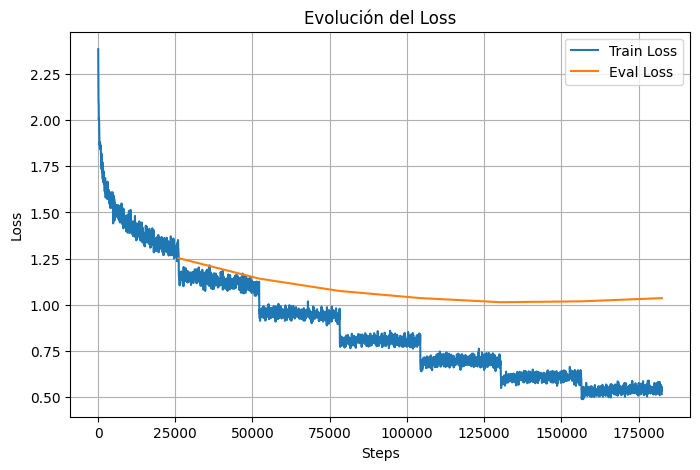

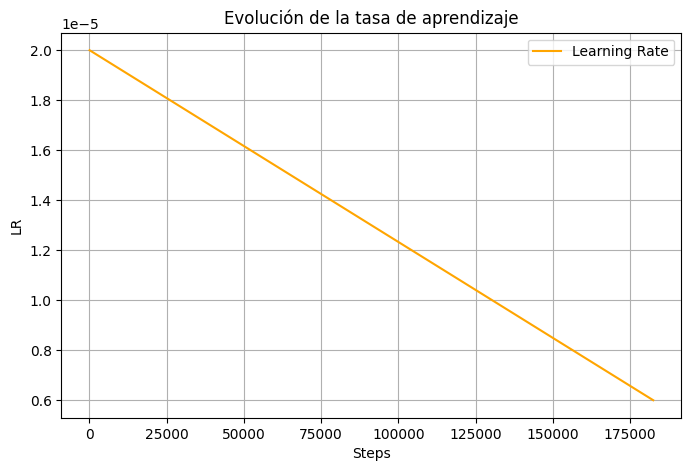

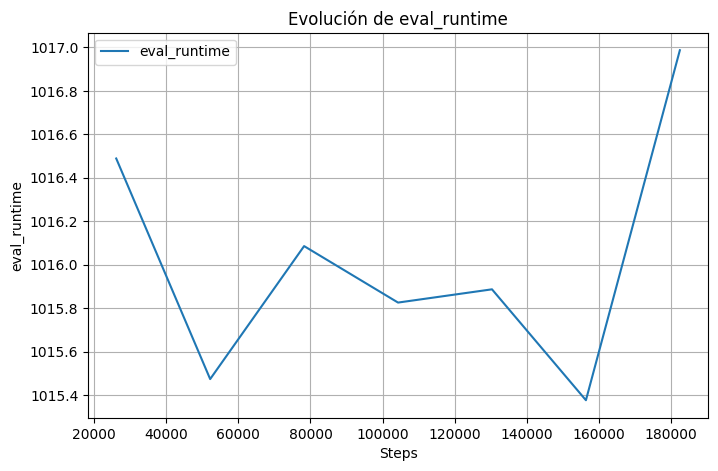

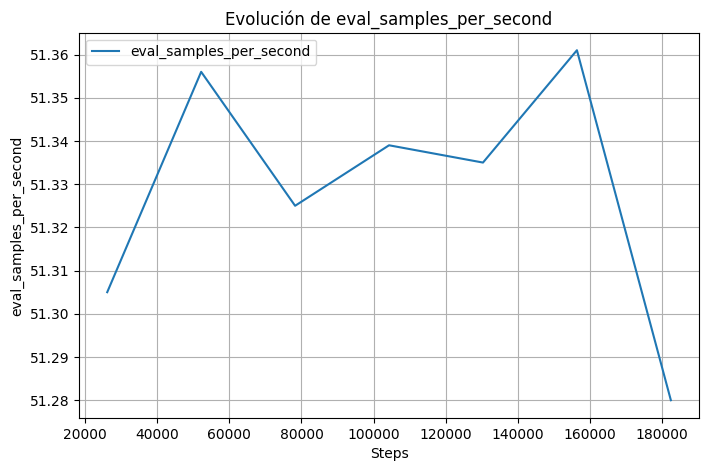

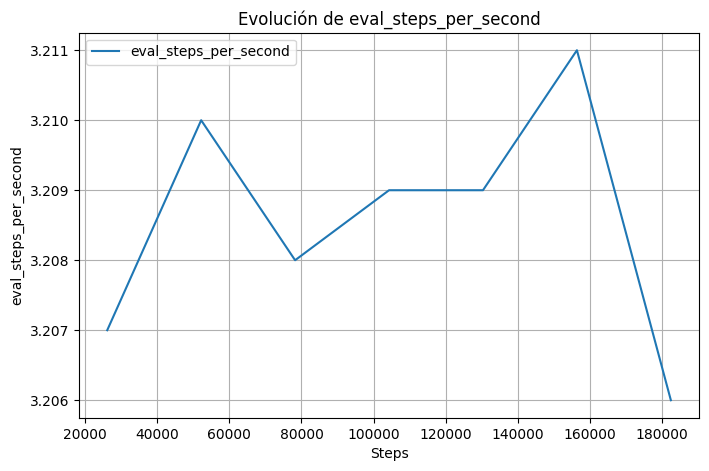

In [14]:
## 10) Mostrar toda la información y gráficas del entrenamiento guardado

import json
import matplotlib.pyplot as plt
from pathlib import Path

# --- Cargar info de la run ---
run_info_path = Path(cfg.output_dir) / "run_info.json"
if run_info_path.exists():
    with open(run_info_path, "r", encoding="utf-8") as f:
        run_info = json.load(f)
    print(" Información del entrenamiento:")
    for k, v in run_info.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {run_info_path}")

# --- Cargar métricas finales ---
metrics_path = Path(cfg.output_dir) / "train_results.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        train_metrics = json.load(f)
    print("\n Métricas finales de entrenamiento:")
    for k, v in train_metrics.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {metrics_path}")

# --- Cargar trainer_state.json para histórico de entrenamiento ---
log_history_path = Path(cfg.output_dir) / "trainer_state.json"
if log_history_path.exists():
    with open(log_history_path, "r", encoding="utf-8") as f:
        trainer_state = json.load(f)

    # Info del mejor checkpoint
    best_ckpt = trainer_state.get("best_model_checkpoint", None)
    if best_ckpt:
        print(f"\n Mejor checkpoint: {best_ckpt}")
    else:
        print("\n No se encontró información del mejor checkpoint.")

    # Historial de métricas
    log_history = trainer_state.get("log_history", [])

    # Extraer métricas y pasos
    steps_train = [entry["step"] for entry in log_history if "loss" in entry]
    train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

    steps_eval = [entry["step"] for entry in log_history if "eval_loss" in entry]
    eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

    learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]
    steps_lr = [entry["step"] for entry in log_history if "learning_rate" in entry]

    # Detectar métricas adicionales
    extra_metrics = {}
    for entry in log_history:
        for k, v in entry.items():
            if k.startswith("eval_") and k not in ["eval_loss"]:
                extra_metrics.setdefault(k, {"steps": [], "values": []})
                extra_metrics[k]["steps"].append(entry["step"])
                extra_metrics[k]["values"].append(v)

    # --- Gráfica loss ---
    plt.figure(figsize=(8,5))
    plt.plot(steps_train, train_loss, label="Train Loss")
    plt.plot(steps_eval, eval_loss, label="Eval Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Evolución del Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Gráfica learning rate ---
    if learning_rates:
        plt.figure(figsize=(8,5))
        plt.plot(steps_lr, learning_rates, label="Learning Rate", color="orange")
        plt.xlabel("Steps")
        plt.ylabel("LR")
        plt.title("Evolución de la tasa de aprendizaje")
        plt.legend()
        plt.grid(True)
        plt.show()

    # --- Gráficas de métricas adicionales ---
    for metric_name, data in extra_metrics.items():
        plt.figure(figsize=(8,5))
        plt.plot(data["steps"], data["values"], label=metric_name)
        plt.xlabel("Steps")
        plt.ylabel(metric_name)
        plt.title(f"Evolución de {metric_name}")
        plt.legend()
        plt.grid(True)
        plt.show()

else:
    print(f" No se encontró {log_history_path}")

## 11) Evaluación (BLEU con SacreBLEU)

In [15]:
## 11) Evaluación robusta + Métricas (SacreBLEU, chrF, TER, ROUGE-L, METEOR) — PyTorch

# Instalar dependencias (solo si no las tienes)

from tqdm.auto import tqdm
import sacrebleu
from sacrebleu.metrics import CHRF, TER
from rouge_score import rouge_scorer
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import wordpunct_tokenize
import numpy as np
import torch
import json
from bert_score import score as calc_bertscore
from comet import download_model, load_from_checkpoint

import time
start = time.time()

# Descargar recursos de NLTK (para METEOR)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# --- Parámetros ---
EVAL_MAX_SAMPLES = 1000        # None = todo el split
PRED_BEAMS = 4
BATCH_EVAL = max(1, cfg.batch_size // 2)

# --- Comprobaciones ---
assert 'model' in globals(), "No se encontró `model`. Carga el modelo antes."
assert 'tokenizer' in globals(), "No se encontró `tokenizer`. Cárgalo antes."
assert 'val_ds' in globals() and 'test_ds' in globals(), "Faltan `val_ds` y/o `test_ds`."
assert 'cfg' in globals(), "Falta `cfg`."

# Asegurar pad_token_id
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# --- Extraer textos originales desde el dataset tokenizado ---

# --- Seleccionar split ---
eval_raw = test_ds if len(test_ds) > 0 else val_ds
n_total = len(eval_raw)
n_eval = n_total if (EVAL_MAX_SAMPLES is None) else min(n_total, int(EVAL_MAX_SAMPLES))
assert n_eval > 0, "No hay ejemplos para evaluar."
def decode_ids_to_text(dataset, id_col):
    return [
        tokenizer.decode(ids, skip_special_tokens=True)
        for ids in dataset[id_col]
    ]

src_texts = decode_ids_to_text(eval_raw, "input_ids")[:n_eval]
ref_texts = decode_ids_to_text(eval_raw, "labels")[:n_eval]


# --- Generación por lotes ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def batched_generate(texts, batch_size=8, max_length=128, num_beams=4):
    preds = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=cfg.max_source_length
            ).to(device)
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True,
                forced_bos_token_id=tokenizer.lang_code_to_id[cfg.tgt_lang]
            )
            preds.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    return preds

preds = batched_generate(
    src_texts,
    batch_size=BATCH_EVAL,
    max_length=cfg.max_target_length,
    num_beams=PRED_BEAMS
)

# --- Métricas ---
# bleu_corpus = sacrebleu.corpus_bleu(preds, [ref_texts]).score

# chrf_metric = CHRF(word_order=2)
# chrf_corpus = chrf_metric.corpus_score(preds, [ref_texts]).score

# ter_metric = TER()
# ter_corpus = ter_metric.corpus_score(preds, [ref_texts]).score

# def compute_rougeL_f1(hyp_list, ref_list):
#     scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
#     f1s = []
#     for h, r in zip(hyp_list, ref_list):
#         s = scorer.score(r, h)
#         f1s.append(s['rougeL'].fmeasure)
#     return float(np.mean(f1s)) * 100.0
# rougeL_f1 = compute_rougeL_f1(preds, ref_texts)

# def compute_meteor(hyp_list, ref_list):
#     scores = []
#     for hyp, ref in zip(hyp_list, ref_list):
#         hyp_tok = wordpunct_tokenize(hyp) if isinstance(hyp, str) else hyp
#         ref_tok = wordpunct_tokenize(ref) if isinstance(ref, str) else ref
#         scores.append(meteor_score([ref_tok], hyp_tok))
#     return float(np.mean(scores)) * 100.0
# meteor_avg = compute_meteor(preds, ref_texts)


# --- BERTSCORE ---
print("Calculando BERTScore...")
# Extraemos el idioma destino desde cfg (si no lo tienes configurado así, cámbialo por "en", "es", etc.)
tgt_language = getattr(cfg, "tgt_lang", "multilingual")
_, _, F1 = calc_bertscore(preds, ref_texts, lang=tgt_language, verbose=False)
bertscore_avg = float(F1.mean()) * 100.0

# --- COMET ---
print("Calculando COMET (puede tardar un poco en cargar la primera vez)...")
comet_model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_model_path)
comet_model.eval()

# COMET necesita el texto original (src), la predicción (mt) y la referencia (ref)
comet_data = [
    {"src": s, "mt": p, "ref": r} 
    for s, p, r in zip(src_texts, preds, ref_texts)
]
comet_output = comet_model.predict(comet_data, batch_size=BATCH_EVAL, progress_bar=True)
comet_avg = float(comet_output.system_score) * 100.0

end_time = time.time()

results = {
    "model" : getattr(cfg, "model_ckpt", "unknown_model"),
    "n_eval": n_eval,
    "num_beams": PRED_BEAMS,
    "batch_eval": BATCH_EVAL,
    # "sacrebleu": round(bleu_corpus, 4),
    # "chrf2": round(chrf_corpus, 4),
    # "ter": round(ter_corpus, 4),
    # "rougeL_f1": round(rougeL_f1, 4),
    # "meteor": round(meteor_avg, 4), 
    "bertscore": round(bertscore_avg, 4),
    "comet": round(comet_avg, 4),
    "execution_time": round(end_time - start, 2)
}

if hasattr(cfg, "evaluation_dir"):
    os.makedirs(cfg.evaluation_dir, exist_ok=True)
    res_file = os.path.join(cfg.evaluation_dir, getattr(cfg, "results_file", "results.json"))
    with open(res_file, "a", encoding="utf-8") as f:
        f.write("\n")
        f.write(json.dumps(results, ensure_ascii=False, indent=4))

print("\n--- RESULTADOS FINALES ---")
print(json.dumps(results, indent=4))


c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\torchmetrics\utilities\imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/125 [00:00<?, ?it/s]

Calculando BERTScore...
Calculando COMET (puede tardar un poco en cargar la primera vez)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\Usuario\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
Encoder model frozen.
c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to e


--- RESULTADOS FINALES ---
{
    "model": "facebook/mbart-large-50-many-to-many-mmt",
    "n_eval": 1000,
    "num_beams": 4,
    "batch_eval": 8,
    "bertscore": 86.7993,
    "comet": 79.9604,
    "execution_time": 1014.25
}


In [16]:
# tid = tokenizer.lang_code_to_id[cfg.tgt_lang]
# model.config.forced_bos_token_id = tid
# model.config.decoder_start_token_id = tid
# model.generation_config.forced_bos_token_id = tid

## 12) Muestra cualitativa (n ejemplos aleatorios)

In [17]:
import random
import torch

# Mostrar predicciones aleatorias para inspección
n_show = 100
idxs = random.sample(range(len(eval_raw)), k=min(n_show, len(eval_raw)))

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for i in idxs:
    # Decodificar texto fuente y referencia desde dataset tokenizado
    zh = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
    en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

    # Tokenizar entrada y mover a dispositivo
    inputs = tokenizer(zh, return_tensors="pt").to(device)

    # Generar traducción
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=cfg.max_target_length,
            num_beams=4,
            early_stopping=True,
            forced_bos_token_id=tokenizer.lang_code_to_id[cfg.tgt_lang]
        )

    en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

    print("="*80)
    print("ZH:", zh)
    print("EN (ref):", en_ref)
    print("EN (pred):", en_pred)


ZH: 最关键的是——真正的天庭,不是在这里,而是在我们的心中
EN (ref): And most importantly, the true Heavenly Court is not here, it is within our hearts
EN (pred): And most importantly, true Heavenly Court is not here, it is in our hearts
ZH: 这一切他都清楚,可他还是脚步停顿下来,没有选择离去,因为 他不能错过这个机会,一旦错过,哪怕是在这炼魂壶的世界内,他想要去找到白浩,也都极为艰难,且一旦在这过程中,白浩的魂出现了灭亡,那么将是他一生的遗憾
EN (ref): He could not pass up this oppor tunity. After all, even knowing that Bai Hao’s soul was in the Necromancer Kettle wouldn’t necessarily do much good. Even going to search for him in that one particular area would be difficult. Furthermore, if Bai Hao’s soul were to die, then Bai Xiaochun would feel regret over the matter for the rest of his life
EN (pred): He knew all of this clearly, and yet, chose not to leave. He couldn’t miss this oppor tunity. Even in this Necromancer Kettle, it would be very difficult to find Bai Hao, and if he lost him in the process, it would be a life-or-death regret
ZH: 我不信
EN (ref): I do not believe it
EN (pred): I do not believe you
ZH:

In [18]:
# from tqdm import tqdm
# os.makedirs(cfg.translate_dir, exist_ok=True)
# translate_path = os.path.join(cfg.translate_dir, cfg.translate_file)

# with open(translate_path, "w", encoding="utf-8") as f:
#     for i in tqdm(range(len(eval_raw) // 10)):
#         zh = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
#         en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

#         # Tokenizar entrada y mover a dispositivo
#         inputs = tokenizer(zh, return_tensors="pt").to(device)

#         # Generar traducción
#         with torch.no_grad():
#             out = model.generate(
#                 **inputs,
#                 max_length=cfg.max_target_length,
#                 num_beams=4,
#                 early_stopping=True,
#                 forced_bos_token_id=tokenizer.lang_code_to_id[cfg.tgt_lang]
#             )

#         en_pred = tokenizer.decode(out[0], skip_special_tokens=True)


#         # Guardar en el archivo
#         f.write("="*80 + "\n")
#         f.write("ZH: " + zh + "\n")
#         f.write("EN (ref): " + en_ref + "\n")
#         f.write("EN (pred): " + en_pred + "\n\n")


In [19]:

# # ==============================================================================
# # CÓDIGO PARA EXTRAER MÉTRICAS DE DIFICULTAD (DATA CARTOGRAPHY)
# # Añadir al final de cada notebook
# # ==============================================================================

# import torch
# import pandas as pd
# import sacrebleu
# from tqdm.auto import tqdm
# from sacrebleu.metrics import CHRF
# # 1. Configuración
# # ----------------
# BATCH_SIZE = 64  # Aumenta si tienes VRAM, disminuye si da OOM
# OUTPUT_FILE = f"scores_{cfg.model_ckpt.replace('/', '_')}.csv"
# SRC_COL = cfg.src_col 
# TGT_COL = cfg.tgt_col

# print(f"--> Iniciando inferencia sobre el TRAIN SET para: {cfg.model_ckpt}")
# print(f"--> Archivo de salida: {OUTPUT_FILE}")

# # 2. Preparar Modelo
# # ------------------
# model.eval()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # Asegurar configuración de idioma para modelos multilingües (mBART, M2M100)
# if hasattr(tokenizer, "src_lang") and hasattr(cfg, "src_lang"):
#     tokenizer.src_lang = cfg.src_lang
# # Para mBART/M2M100 forzamos el token de inicio si es necesario
# if hasattr(model.config, "forced_bos_token_id") and hasattr(tokenizer, "lang_code_to_id"):
#     try:
#         # Intentar obtener el ID del idioma target
#         lang_id = tokenizer.lang_code_to_id.get(cfg.tgt_lang, None)
#         if lang_id is not None:
#             model.config.forced_bos_token_id = lang_id
#     except:
#         pass

# # 3. Loop de Inferencia sobre Train
# # ---------------------------------
# # Usamos raw_ds['train'] para tener el texto crudo y calcular BLEU real
# dataset = raw_ds['train'] 
# # dataset = dataset.select(range(1000)) # DESCOMENTAR PARA PROBAR RAPIDO

# results_indices = []
# results_scores = []

# # Iterar por batches
# for i in tqdm(range(0, len(dataset), BATCH_SIZE), desc="Generando"):
#     batch = dataset[i : i + BATCH_SIZE]
#     src_texts = batch[SRC_COL]
#     tgt_texts = batch[TGT_COL] # Referencias reales
    
#     # a) Tokenizar
#     inputs = tokenizer(
#         src_texts, 
#         padding=True, 
#         truncation=True, 
#         max_length=cfg.max_source_length, 
#         return_tensors="pt"
#     ).to(device)
    
#     # b) Generar (Greedy Search para velocidad)
#     with torch.no_grad():
#         generated_ids = model.generate(
#             **inputs, 
#             max_new_tokens=cfg.max_target_length, 
#             num_beams=1, 
#             do_sample=False,
#             early_stopping=False
#         )
    
#     # c) Decodificar
#     decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
#     chrf_metric = CHRF(word_order=2)
#     # d) Calcular Sentence-chrf
#     for idx, (pred, ref) in enumerate(zip(decoded_preds, tgt_texts)):
        

#         score = sacrebleu.sentence_chrf(pred, [ref]).score        
#         # Guardar el índice original del dataset y el score
#         results_indices.append(i + idx)
#         results_scores.append(score)

# # 4. Guardar Resultados
# # ---------------------
# df_scores = pd.DataFrame({
#     'id': results_indices,
#     'chrf': results_scores
# })

# # Guardamos en la carpeta de processed_data o donde prefieras
# save_path = BASE_DIR / "processed_data" / OUTPUT_FILE
# df_scores.to_csv(save_path, index=False)
# print(f" Scores guardados en: {save_path}")